In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from joblib import parallel_backend
from sklearn.svm import SVR

In [43]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "dfFinalMA_Train/MA_TRAIN.csv"
path_test  = "dfFinalMA_Test/MA_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 6375 filas, 15 columnas
Dimensiones de Test:  1608 filas, 15 columnas

--- Tipos de datos en Train ---
User_ID                       object
Age                            int64
Gender                        object
User_Archetype                object
Primary_Platform              object
Daily_Screen_Time_Hours      float64
Dominant_Content_Type         object
Activity_Type                 object
Late_Night_Usage                bool
Social_Comparison_Trigger       bool
Sleep_Duration_Hours         float64
GAD_7_Score                    int64
GAD_7_Severity                object
PHQ_9_Score                    int64
PHQ_9_Severity                object
dtype: object

--- Primeras 5 filas de Train ---


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-00061085,19,MALE,PASSIVE SCROLLER,FACEBOOK,4.0,NEWS/POLITICS,PASSIVE,True,False,5.8,8,MILD,8,MILD
1,U-00088ACC,20,MALE,PASSIVE SCROLLER,TIKTOK,4.0,NEWS/POLITICS,PASSIVE,True,False,4.2,10,MODERATE,7,MILD
2,U-000A7FEC,20,MALE,AVERAGE USER,INSTAGRAM,3.6,LIFESTYLE/FASHION,ACTIVE,False,True,6.9,10,MODERATE,0,NONE-MINIMAL
3,U-00228E6E,19,MALE,PASSIVE SCROLLER,YOUTUBE,3.1,LIFESTYLE/FASHION,PASSIVE,False,False,6.2,7,MILD,9,MILD
4,U-00262C0F,18,FEMALE,AVERAGE USER,LINKEDIN,2.4,EDUCATIONAL/TECH,ACTIVE,False,False,6.4,9,MILD,1,NONE-MINIMAL


In [44]:
# 1. Definir la variable objetivo
target_col = "PHQ_9_Score"

columnas_a_dropear = [
    "User_ID",                 
    "GAD_7_Severity",
    "GAD_7_Score",
    "PHQ_9_Severity"
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (6375, 10)
Dimensiones de y_train (Objetivo):    (6375,)
Dimensiones de X_test (Predictoras):  (1608, 10)
Dimensiones de y_test (Objetivo):     (1608,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours']


In [45]:
# 1. Identificar cuáles son las columnas numéricas
# Seleccionamos solo las columnas de tipo entero y decimal
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. Ajustar (fit) y transformar (transform) el conjunto de TRAIN
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])

# 4. Transformar SOLO (transform) el conjunto de TEST
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                       -0.0
Daily_Screen_Time_Hours    0.0
Sleep_Duration_Hours       0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                        1.0
Daily_Screen_Time_Hours    1.0
Sleep_Duration_Hours       1.0
dtype: float64

--- Primeras filas de X_train escalado ---


,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours
0,-0.050239,MALE,PASSIVE SCROLLER,FACEBOOK,-0.107376,NEWS/POLITICS,PASSIVE,True,False,-0.015770
1,0.846880,MALE,PASSIVE SCROLLER,TIKTOK,-0.107376,NEWS/POLITICS,PASSIVE,True,False,-1.215309
2,0.846880,MALE,AVERAGE USER,INSTAGRAM,-0.281100,LIFESTYLE/FASHION,ACTIVE,False,True,0.808913
3,-0.050239,MALE,PASSIVE SCROLLER,YOUTUBE,-0.498256,LIFESTYLE/FASHION,PASSIVE,False,False,0.284114
4,-0.947357,FEMALE,AVERAGE USER,LINKEDIN,-0.802275,EDUCATIONAL/TECH,ACTIVE,False,False,0.434057


In [ ]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type','Activity_Type']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 51


In [29]:
# 1. Definir el modelo base
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=46)

# 2. Definir la parrilla de hiperparámetros que quieres probar
param_grid = {
    'n_estimators': [50, 100, 200,500,1000,2000],       # Número de árboles
    'learning_rate': [0.01, 0.05, 0.1,0.2],     # Tasa de aprendizaje
    'max_depth': range(1,10),                 # Profundidad de los árboles
}

# 3. Configurar el GridSearch con Validación Cruzada (5 folds)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='r2',          # Buscaremos maximizar el R2
    cv=5,                  # 5 folds
    n_jobs=-1,             # Usa todos los núcleos de tu CPU para acelerar
    verbose=1              # Muestra el progreso por consola
)

print("--- Iniciando búsqueda de hiperparámetros (Grid Search) ---")
grid_search.fit(X_train_codificado, y_train)

# 4. Ver los mejores resultados
print("\n==============================================")
print("       MEJORES HIPERPARÁMETROS ENCONTRADOS    ")
print("==============================================")
print(grid_search.best_params_)
print(f"Mejor R2 en Validación Cruzada: {grid_search.best_score_:.4f}")

--- Iniciando búsqueda de hiperparámetros (Grid Search) ---
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

       MEJORES HIPERPARÁMETROS ENCONTRADOS    
{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 500}
Mejor R2 en Validación Cruzada: 0.4993


Primeras filas de los resultados de las combinaciones:


,param_max_depth,param_learning_rate,mean_test_score
0,1,0.01,0.279953
1,1,0.01,0.390138
2,1,0.01,0.464038
3,1,0.01,0.497254
4,1,0.01,0.498894


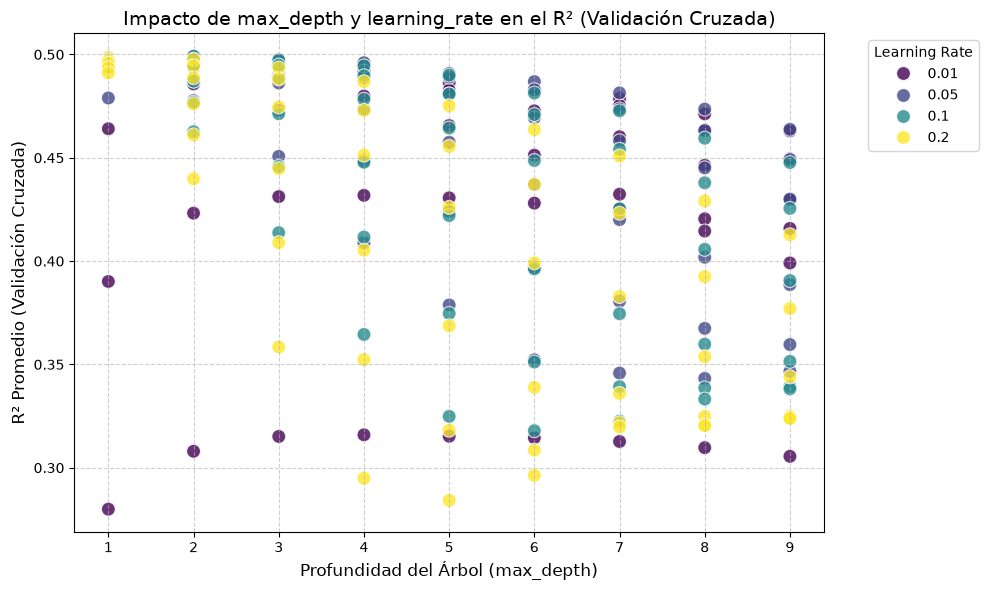

<Figure size 1000x800 with 0 Axes>

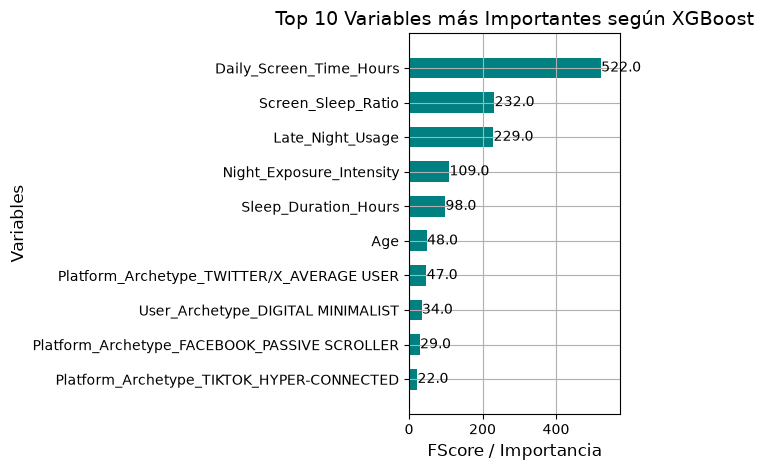

In [30]:
# 1. Convertir los resultados de la búsqueda Grid  en un DataFrame de Pandas
resultados_df = pd.DataFrame(grid_search.cv_results_)

# 2. Vista previa de los datos recolectados
print("Primeras filas de los resultados de las combinaciones:")
display(resultados_df[['param_max_depth', 'param_learning_rate', 'mean_test_score']].head())

# ==========================================
# GRÁFICA 1: Impacto de 'max_depth' y 'learning_rate' en el R2
# ==========================================
plt.figure(figsize=(10, 6))

# Usamos un gráfico de dispersión
sns.scatterplot(
    data=resultados_df,
    x='param_max_depth',
    y='mean_test_score',
    hue='param_learning_rate',
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.title('Impacto de max_depth y learning_rate en el R² (Validación Cruzada)', fontsize=14)
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=12)
plt.ylabel('R² Promedio (Validación Cruzada)', fontsize=12)
plt.legend(title='Learning Rate', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICA 2: Importancia de características del mejor modelo
# ==========================================
mejor_modelo = grid_search.best_estimator_

plt.figure(figsize=(10, 8))
# XGBoost incluye una función nativa para plotear la importancia
xgb.plot_importance(mejor_modelo, max_num_features=10, height=0.6, color='teal')
plt.title('Top 10 Variables más Importantes según XGBoost', fontsize=14)
plt.xlabel('FScore / Importancia', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()

--- Resultados en Test ---
RMSE: 3.4890
MAE:  2.8136
R2:   0.4706


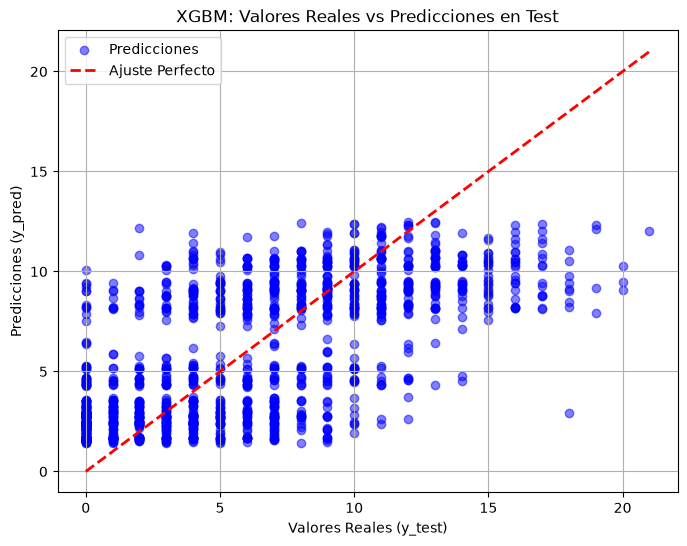

In [31]:
y_pred = grid_search.predict(X_test_codificado)

y_test_original = y_test

# 2. Métricas en escala real
rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae_test = mean_absolute_error(y_test_original, y_pred)
r2_test = r2_score(y_test_original, y_pred)

print("--- Resultados en Test ---")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE:  {mae_test:.4f}")
print(f"R2:   {r2_test:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5, color='b', label='Predicciones')

min_val = min(np.min(y_test_original), np.min(y_pred))
max_val = max(np.max(y_test_original), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ajuste Perfecto')

plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (y_pred)')
plt.title('XGBM: Valores Reales vs Predicciones en Test')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# con SVM

vectorC = np.logspace(-3, 3, 20) 
vectorG = np.logspace(-4, 2, 20)

param_grid = {'C': vectorC, 'gamma':vectorG}

with parallel_backend('threading', n_jobs=4):
    grid = GridSearchCV(SVR(kernel='rbf'), param_grid=param_grid, cv = 5, scoring='r2')
    grid.fit(X_train_codificado, y_train)
print("best R2: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

print("Gamma en la gráfica: ", np.log10(grid.best_params_['gamma']))
print("C en la gráfica: ", np.log10(grid.best_params_['C']))

# Mostramos prestaciones en CV
scores = grid.cv_results_['mean_test_score'].reshape(len(vectorC),len(vectorG))



best R2: 0.482
best parameters: {'C': np.float64(233.57214690901213), 'gamma': np.float64(0.0001)}
Gamma en la gráfica:  -4.0
C en la gráfica:  2.3684210526315788


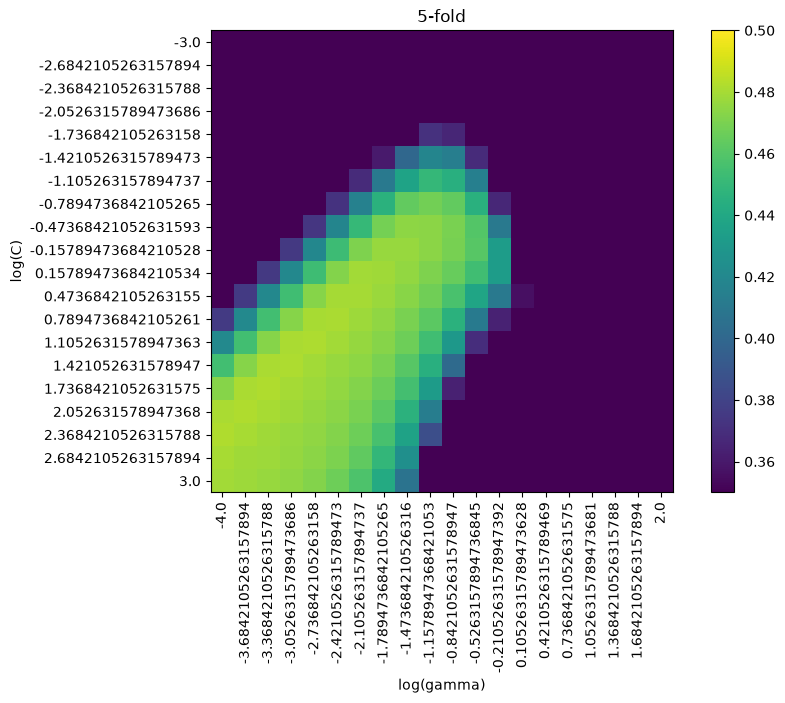

In [14]:
plt.figure(figsize=(10,6))
plt.imshow(scores, interpolation='nearest', vmin= 0.35, vmax=0.5)
plt.xlabel('log(gamma)')
plt.ylabel('log(C)')
plt.colorbar()
plt.xticks(np.arange(len(vectorG)), np.log10(vectorG), rotation=90)
plt.yticks(np.arange(len(vectorC)), np.log10(vectorC))
plt.title('5-fold')
plt.show()

--- Resultados en Test ---
RMSE: 3.5611
MAE:  2.7715
R2:   0.4485


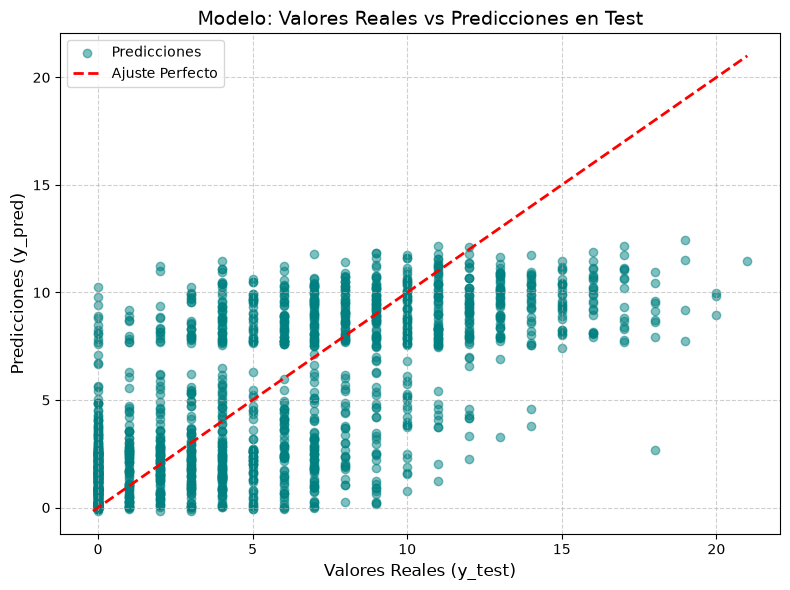

In [15]:
# 1. Obtenemos las predicciones sobre el conjunto de Test usando el mejor modelo del GridSearch
y_pred = grid.best_estimator_.predict(X_test_codificado)  # Cambia 'grid' por 'grid_search' si así lo llamaste

y_test_original = y_test

# 2. Cálculo de métricas en escala real
rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae_test = mean_absolute_error(y_test_original, y_pred)
r2_test = r2_score(y_test_original, y_pred)

print("--- Resultados en Test ---")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE:  {mae_test:.4f}")
print(f"R2:   {r2_test:.4f}")

# 3. Gráfica de dispersión: Valores Reales vs Predicciones
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5, color='teal', label='Predicciones')

# Línea diagonal de ajuste perfecto (y = x)
min_val = min(np.min(y_test_original), np.min(y_pred))
max_val = max(np.max(y_test_original), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ajuste Perfecto')

plt.xlabel('Valores Reales (y_test)', fontsize=12)
plt.ylabel('Predicciones (y_pred)', fontsize=12)
plt.title('Modelo: Valores Reales vs Predicciones en Test', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()